In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
%pip install torch
%pip install kaggle
%pip install torchvision
%pip install scikit-image
%pip install numpy

In [ ]:
from google.colab import files
files.upload()  # select kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayushipathak06","key":"dadf2c9927774830435129b6822e19e5"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Dataset Preparation

In [ ]:
!kaggle datasets download -d requiemonk/sentinel12-image-pairs-segregated-by-terrain

Dataset URL: https://www.kaggle.com/datasets/requiemonk/sentinel12-image-pairs-segregated-by-terrain
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.54G/2.55G [00:23<00:00, 165MB/s]
100% 2.55G/2.55G [00:23<00:00, 114MB/s]


In [ ]:
%%capture
!unzip sentinel12-image-pairs-segregated-by-terrain.zip
!rm -rf sentinel12-image-pairs-segregated-by-terrain.zip

In [ ]:
import os
print(os.getcwd())  # current working directory
print(os.listdir())  # list files in current directory


/content
['.config', 'drive', 'v_2', 'kaggle.json', 'sample_data']


In [ ]:
import os
opt = []
sar = []
root_dir = './v_2'
for dir in os.listdir(root_dir):
  path = os.path.join(root_dir, dir)
  s1, s2  = os.listdir(path)
  if s1 == 's2':
    print(s1)
    for file in os.listdir(os.path.join(path, s1)):
      if file.endswith('.png'):
        opt.append(os.path.join(path, s1, file))
    for file in os.listdir(os.path.join(path, s2)):
      if file.endswith('.png'):
        sar.append(os.path.join(path, s2, file))
  if s1 == 's1':
    for file in os.listdir(os.path.join(path, s1)):
      if file.endswith('.png'):
        sar.append(os.path.join(path, s1, file))
    for file in os.listdir(os.path.join(path, s2)):
      if file.endswith('.png'):
        opt.append(os.path.join(path, s2, file))
opt = sorted(opt)
sar = sorted(sar)
print(len(opt), len(sar))


16000 16000


# **Implementing Colorization Model**

In [ ]:
import cv2
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt



## Preparing dataset for colorization model

In [ ]:
from torchvision import transforms
from skimage.color import rgb2lab, lab2rgb

def rgb_to_lab(img):

    img_lab = rgb2lab(img).astype("float32")
    img_lab = transforms.ToTensor()(img_lab)
    L_channel = img_lab[[0], ...]
    ab_channels = img_lab[[1, 2], ...]
    # scale between -1 to 1
    L_channel = 2 * (L_channel - (0)) / (100 - (0)) - 1
    ab_channels = 2 * (ab_channels - (-128)) / (127 - (-128)) - 1

    return L_channel, ab_channels

In [ ]:
def create_patches(img, patch_size=224):
    patches = []
    h, w = img.shape[1:]

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch = img[:, i:i + patch_size, j:j + patch_size]
            if patch.shape[1:] == (patch_size, patch_size):
                patches.append(patch)

    return patches

In [ ]:
class ColorizationDataset(Dataset):
    def __init__(self, color_dir, transform=None, patch_size=224):
        self.color_dir = color_dir
        self.transform = transform
        self.patch_size = patch_size

    def __len__(self):
        return len(self.color_dir)

    def __getitem__(self, idx):

        color_img = np.array(Image.open(self.color_dir[idx]))
        color_img = cv2.resize(color_img, (224, 224))

        # Convert to Lab color space
        L_channel, ab_channels = rgb_to_lab(color_img)

        return L_channel, ab_channels

In [ ]:
dataset = ColorizationDataset( opt[:10000])

# Split dataset into training and validation
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, drop_last=True)




In [ ]:
# Load a batch and print the shapes of the patches
for L_patches, ab_patches in train_loader:
    print(f"L_patches shape: {L_patches.shape}")
    print(f"ab_patches shape: {ab_patches.shape}")
    print(L_patches[0])
    break

L_patches shape: torch.Size([8, 1, 224, 224])
ab_patches shape: torch.Size([8, 2, 224, 224])
tensor([[[ 0.5187,  0.4230,  0.4366,  ..., -0.0247,  0.0093,  0.1494],
         [ 0.5199,  0.4246,  0.4433,  ...,  0.1016,  0.0961,  0.1547],
         [ 0.5214,  0.4530,  0.4952,  ...,  0.1324,  0.1403,  0.1139],
         ...,
         [-0.3926, -0.3345, -0.3080,  ..., -0.1920, -0.2102, -0.1631],
         [-0.3323, -0.4561, -0.4676,  ..., -0.3428, -0.3520, -0.2544],
         [-0.1782, -0.3139, -0.3655,  ..., -0.3221, -0.2002, -0.1126]]])


## Implementing the Encoder

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet50_Weights, DenseNet121_Weights

class EnsembleEncoder(nn.Module):
    def __init__(self):
        super(EnsembleEncoder, self).__init__()

        # Load pre-trained ResNet50 and DenseNet121
        self.resnet50 = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.densenet121 = models.densenet121(weights=DenseNet121_Weights.DEFAULT)

        self.resnet50 = nn.Sequential(*list(self.resnet50.children())[:-2])
        # self.densenet121 = nn.Sequential(*list(self.densenet121.children())[:-1])
        self.densenet121.classifier = nn.Identity()


        # Custom layers for fusion
        self.conv1x1_resnet50 = nn.ModuleList([
            nn.Conv2d(256, 128, kernel_size=1),
            nn.Conv2d(512, 256, kernel_size=1),
            nn.Conv2d(1024, 512, kernel_size=1),
            nn.Conv2d(2048, 1024, kernel_size=1)
        ])

        self.conv1x1_densenet121 = nn.ModuleList([
            nn.Conv2d(256, 128, kernel_size=1),
            nn.Conv2d(512, 256, kernel_size=1),
            nn.Conv2d(1024, 512, kernel_size=1),
            nn.Conv2d(1024, 1024, kernel_size=1)
        ])

        self.fusion_blocks = nn.ModuleList([
            self.fusion_block(128, 128),
            self.fusion_block(256, 256),
            self.fusion_block(512, 512),
            self.fusion_block(1024, 1024)
        ])

    # Fusion block
    def fusion_block(self, in_channels_resnet, in_channels_densenet):
        return nn.Sequential(
            nn.Conv2d(in_channels_resnet + in_channels_densenet, in_channels_resnet, kernel_size=1),
            nn.BatchNorm2d(in_channels_resnet),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Forward pass through ResNet50
        resnet_features = []
        resnet_input = x
        for i, layer in enumerate(self.resnet50.children()):
            resnet_input = layer(resnet_input)
            if i in [4, 5, 6, 7]:  # Extract features after specific layers
                resnet_features.append(self.conv1x1_resnet50[i-4](resnet_input))

        # Forward pass through DenseNet121
        densenet_features = []
        idx = 0
        densenet_input = x
        for i, layer in enumerate(self.densenet121.features):
            densenet_input = layer(densenet_input)
            if i in [ 4, 6, 8, 11]:
                densenet_features.append(self.conv1x1_densenet121[idx](densenet_input))
                idx += 1


        fused_features = []
        for i in range(4):
            fused = torch.cat((resnet_features[i], densenet_features[i]), dim=1)
            fused = self.fusion_blocks[i](fused)
            fused_features.append(fused)

        return fused_features


## Implementing the Decoder

In [ ]:
import torch
import torch.nn as nn

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()

        # Decoder block 1: Takes input from Fusion Block 4
        self.decode1 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 7x7 -> 14x14
        )

        # Decoder block 2: Takes input from Decoder Block 1 + Fusion Block 3 (512 + 512 channels)
        self.decode2 = nn.Sequential(
            nn.Conv2d(512 + 512, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 14x14 -> 28x28
        )

        # Decoder block 3: Takes input from Decoder Block 2 + Fusion Block 2 (256 + 256 channels)
        self.decode3 = nn.Sequential(
            nn.Conv2d(256 + 256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 28x28 -> 56x56
        )

        # Decoder block 4: Takes input from Decoder Block 3 + Fusion Block 1 (128 + 128 channels)
        self.decode4 = nn.Sequential(
            nn.Conv2d(128 + 128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 56x56 -> 112x112
        )

        # Final decoder block: Reduce to 2 channels (ab channels)
        self.decode5 = nn.Sequential(
            nn.Conv2d(64, 2, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 112x112 -> 224x224
        )

    def forward(self, features_7x7, features_14x14, features_28x28, features_56x56):
        x = self.decode1(features_7x7)
        x = torch.cat([x, features_14x14], dim=1)
        x = self.decode2(x)

        x = torch.cat([x, features_28x28], dim=1)
        x = self.decode3(x)

        x = torch.cat([x, features_56x56], dim=1)
        x = self.decode4(x)

        output = self.decode5(x)

        return output


## Checking our model

In [ ]:
import torch
import torch.nn as nn

class ColorizationModel(nn.Module):
    def __init__(self, encoder, decoder):
        super(ColorizationModel, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        features_56x56, features_28x28, features_14x14, features_7x7 = self.encoder(x)

        output = self.decoder(features_7x7, features_14x14, features_28x28, features_56x56)

        return output

encoder = EnsembleEncoder()
decoder = Decoder()

model = ColorizationModel(encoder, decoder)

# input data
L_patches = torch.randn(1, 3, 224, 224)

output = model(L_patches)

print("Output shape:", output.shape)  # output shape should be [1, 2, 224, 224]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 157MB/s]


Output shape: torch.Size([1, 2, 224, 224])


## Training the model

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize encoder and decoder
encoder = EnsembleEncoder().to(device)
decoder = Decoder().to(device)

# Freeze the encoder parameters as they are pre-trained
for param in encoder.parameters():
    param.requires_grad = False

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(decoder.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Training loop
num_epochs = 30
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # Training phase
    encoder.eval()
    decoder.train()
    running_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Training)")
    for i, (L_batch, ab_batch) in enumerate(train_bar):
        L, ab = L_batch.to(device), ab_batch.to(device)
        L = L.repeat(1, 3, 1, 1)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        features_56x56, features_28x28, features_14x14, features_7x7 = encoder(L)
        output = decoder(features_7x7, features_14x14, features_28x28, features_56x56)

        # Compute loss
        loss = criterion(output, ab)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Accumulate running loss
        running_loss += loss.item()

        # Update progress bar
        train_bar.set_postfix(loss=f"{running_loss/(i+1):.4f}")

    # Validation phase
    decoder.eval()
    val_loss = 0.0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Validation)")
    with torch.no_grad():
        for i, (L_batch, ab_batch) in enumerate(val_bar):
            L, ab = L_batch.to(device), ab_batch.to(device)
            L = L.repeat(1, 3, 1, 1)  # Replicate grayscale to 3 channels

            # Forward pass
            features_56x56, features_28x28, features_14x14, features_7x7 = encoder(L)
            output = decoder(features_7x7, features_14x14, features_28x28, features_56x56)

            # Compute validation loss
            loss = criterion(output, ab)
            val_loss += loss.item()

            val_bar.set_postfix(loss=f"{val_loss/(i+1):.4f}")

    # Calculate average losses
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Save the best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(decoder.state_dict(), 'model_1.pth')
        print(f"Model saved with validation loss: {best_val_loss:.4f}")

    # Step the scheduler
    scheduler.step(avg_val_loss)

print("Training complete.")


Epoch 1/30 (Validation): 100%|██████████| 200/200 [00:19<00:00, 10.34it/s, loss=0.0057]


Epoch 1/30, Training Loss: 0.0070, Validation Loss: 0.0057
Model saved with validation loss: 0.0057


Epoch 2/30 (Validation): 100%|██████████| 200/200 [00:19<00:00, 10.02it/s, loss=0.0039]


Epoch 2/30, Training Loss: 0.0055, Validation Loss: 0.0039
Model saved with validation loss: 0.0039


Epoch 3/30 (Validation): 100%|██████████| 200/200 [00:19<00:00, 10.08it/s, loss=0.0038]


...

Epoch 28/30, Training Loss: 0.0018, Validation Loss: 0.0024
Model saved with validation loss: 0.0024


Epoch 29/30 (Validation): 100%|██████████| 200/200 [00:18<00:00, 10.55it/s, loss=0.0024]


Epoch 29/30, Training Loss: 0.0018, Validation Loss: 0.0024
Model saved with validation loss: 0.0024


Epoch 30/30 (Validation): 100%|██████████| 200/200 [00:19<00:00, 10.44it/s, loss=0.0025]

Epoch 30/30, Training Loss: 0.0018, Validation Loss: 0.0025
Training complete.


In [ ]:
torch.cuda.empty_cache()

## Load the model

In [ ]:
decoder = Decoder().to(device)
state_dict = torch.load('model_1.pth', map_location=device)  # <-- map_location here
decoder.load_state_dict(state_dict)  # <-- no map_location here


<All keys matched successfully>

## Inference

In [ ]:
# Get a batch from the test loader
dataiter = iter(test_loader)
L_batch, ab_batch = next(dataiter)
L_batch, ab_batch = next(dataiter)
L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)
L_batch = L_batch.repeat(1, 3, 1, 1)

encoder.eval()
decoder.eval()
with torch.no_grad():
    features_56x56, features_28x28, features_14x14, features_7x7 = encoder(L_batch)

    predicted_ab = decoder(features_7x7, features_14x14, features_28x28, features_56x56)


In [ ]:
L_batch = L_batch[:, 0, :, :]
L_batch = L_batch.unsqueeze(1)

L_batch = (L_batch + 1) * 0.5 * 100
# real_L = (real_L + 1) * 0.5 * 100
predicted_ab = ((predicted_ab + 1) * 0.5 * (127 + 128)) - 128
ab_batch = ((ab_batch + 1) * 0.5 * (127 + 128)) - 128

# Combine L and ab channels
predicted_lab = torch.cat([L_batch, predicted_ab], dim=1)
real_lab = torch.cat([L_batch, ab_batch], dim=1)


predicted_lab = predicted_lab.cpu().numpy()
real_lab = real_lab.cpu().numpy()

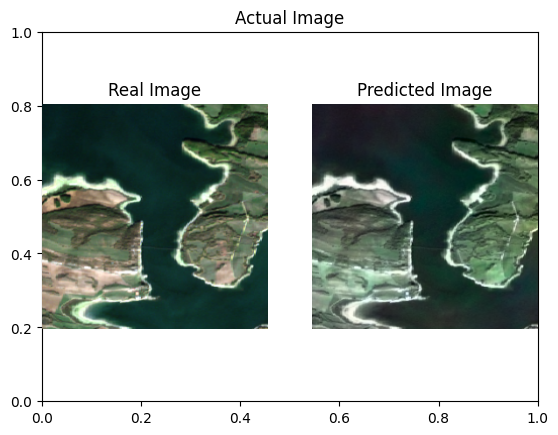

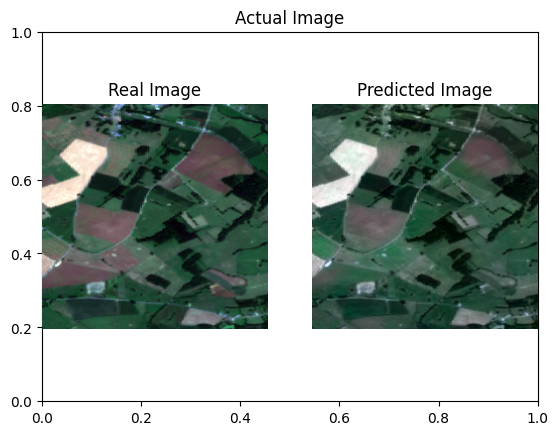

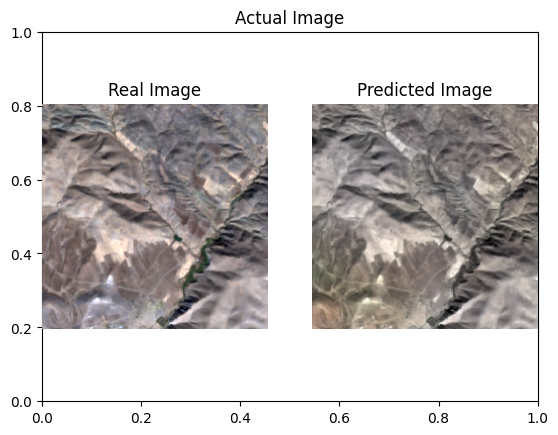

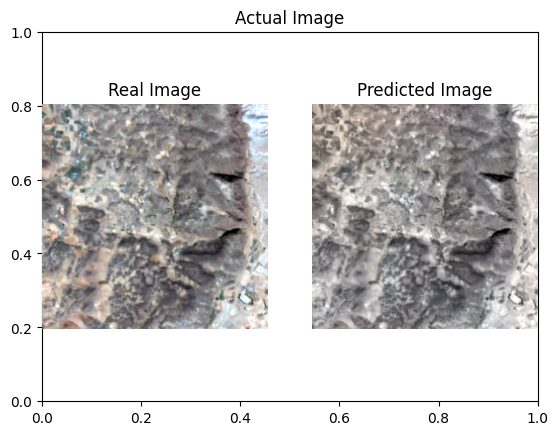

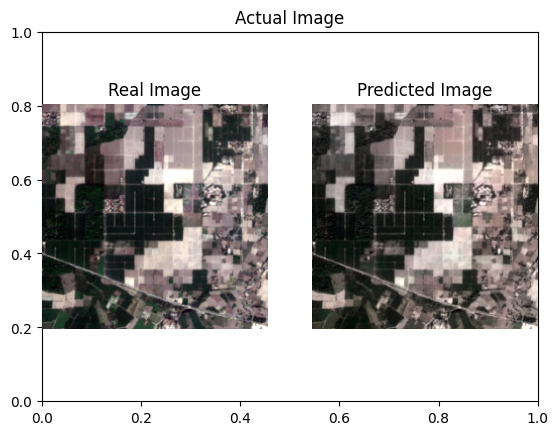

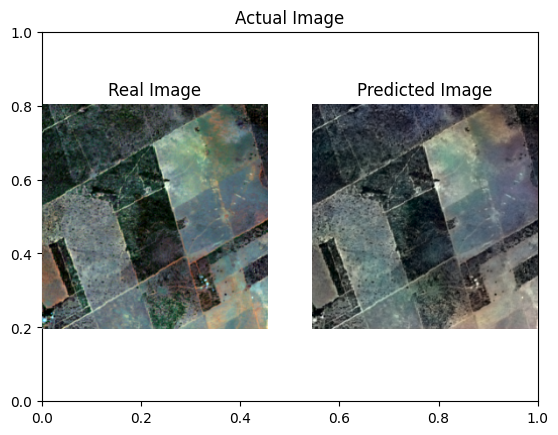

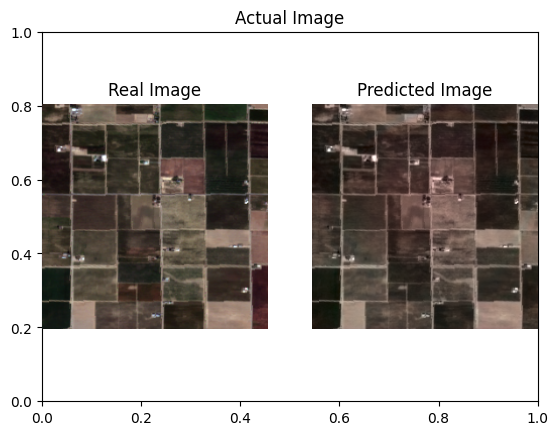

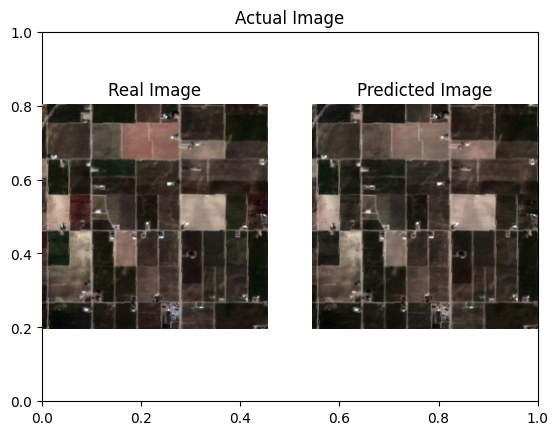

In [ ]:
import numpy as np
from skimage.color import lab2rgb
import matplotlib.pyplot as plt
import cv2


# Iterate over the batch
for i in range(8):

    lab_image = predicted_lab[i]
    real_img = real_lab[i]

    # Transpose to (height, width, 3) for skimage
    lab_image = lab_image.transpose(1, 2, 0).astype(np.float64)
    real_img = real_img.transpose(1, 2, 0).astype(np.float64)

    rgb_image = lab2rgb(lab_image)
    real_rgb = lab2rgb(real_img)

    plt.title('Actual Image')
    plt.subplot(1, 2, 1)
    plt.imshow(real_rgb)
    plt.axis('off')
    plt.title('Real Image')
    plt.subplot(1, 2, 2)
    plt.imshow(rgb_image)
    plt.title('Predicted Image')
    plt.axis('off')
    plt.show()

## Evaulting the Model

In [ ]:
def prediction(model, test_loader):
    encoder.eval()
    model.eval()
    original_images = []
    predicted_images = []

    for L_batch, ab_batch in tqdm(test_loader):
        L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)
        input = L_batch.repeat(1, 3, 1, 1)

        with torch.no_grad():
            features_56x56, features_28x28, features_14x14, features_7x7 = encoder(input)

            predicted_ab = model(features_7x7, features_14x14, features_28x28, features_56x56)
            # predicted_ab = model(input)

        L_batch = (L_batch + 1) * 0.5 * 100
        # real_L = (real_L + 1) * 0.5 * 100
        predicted_ab = ((predicted_ab + 1) * 0.5 * (127 + 128)) - 128
        ab_batch = ((ab_batch + 1) * 0.5 * (127 + 128)) - 128

        # Combine L and ab channels
        predicted_lab = torch.cat([L_batch, predicted_ab], dim=1)
        actual_lab = torch.cat([L_batch, ab_batch], dim=1)

        predicted_lab = predicted_lab.cpu().numpy()
        actual_lab = actual_lab.cpu().numpy()

        predicted_images.extend(predicted_lab)
        original_images.extend(actual_lab)

    return original_images, predicted_images

original_images, predicted_images = prediction(decoder, test_loader)

100%|██████████| 250/250 [00:24<00:00, 10.08it/s]


In [ ]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.color import lab2rgb
import numpy as np

def evaluate_model(original_images, predicted_images):

    total_ssim = 0.0
    total_psnr = 0.0
    total_samples = 0
    for original_img, predicted_img in zip(original_images, predicted_images):
        original_img = lab2rgb(original_img.transpose(1, 2, 0))
        predicted_img = lab2rgb(predicted_img.transpose(1, 2, 0))

        ssim_value = ssim(original_img, predicted_img, multichannel=True, channel_axis=2, data_range=1.0)
        psnr_value = psnr(original_img, predicted_img, data_range=1.0)
        total_ssim += ssim_value
        total_psnr += psnr_value
        total_samples += 1

    average_ssim = total_ssim / total_samples
    average_psnr = total_psnr / total_samples

    return average_ssim, average_psnr

ssim_value, psnr_value = evaluate_model(original_images, predicted_images)
print(f"Average SSIM: {ssim_value:.4f}")
print(f"Average PSNR: {psnr_value:.4f}")



/tmp/ipython-input-798837535.py:13: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2 negative Z values that have been clipped to zero
  predicted_img = lab2rgb(predicted_img.transpose(1, 2, 0))


Average SSIM: 0.9407
Average PSNR: 30.3199


In [ ]:
from skimage.color import lab2rgb
from imageio import imwrite

for i, pred in enumerate(predicted_images[:10]):  # save first 10
    rgb_img = lab2rgb(pred.transpose(1, 2, 0))
    imwrite(f"colorized_{i}.png", (rgb_img * 255).astype("uint8"))


In [ ]:
from google.colab import files
files.download("colorized_0.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save decoder
torch.save(decoder.state_dict(), "decoder.pth")

# Save encoder if needed
torch.save(encoder.state_dict(), "encoder.pth")


Saving karachi-pakistan.jpg to karachi-pakistan.jpg


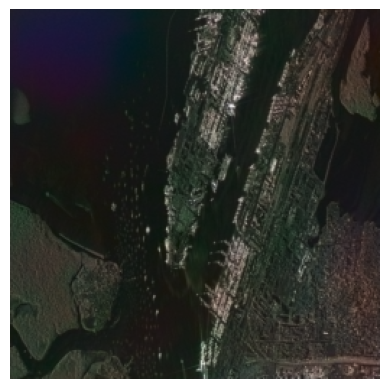

In [ ]:
from PIL import Image
import torch
import torchvision.transforms as T
from skimage.color import lab2rgb
import matplotlib.pyplot as plt

# Load your trained model
decoder.load_state_dict(torch.load("decoder.pth", map_location=device))
decoder.eval()
encoder.eval()

# Upload your own SAR image in Colab
from google.colab import files
uploaded = files.upload()  # select your SAR image

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Preprocess the image
img = Image.open(filename).convert('L')  # grayscale
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])
input_img = transform(img).unsqueeze(0).repeat(1, 3, 1, 1).to(device)

# Run inference
with torch.no_grad():
    features_56x56, features_28x28, features_14x14, features_7x7 = encoder(input_img)
    predicted_ab = decoder(features_7x7, features_14x14, features_28x28, features_56x56)
    L_channel = (input_img[:, 0:1, :, :] + 1) * 0.5 * 100
    predicted_ab = ((predicted_ab + 1) * 0.5 * (127 + 128)) - 128
    predicted_lab = torch.cat([L_channel, predicted_ab], dim=1)
    predicted_lab = predicted_lab.squeeze().cpu().permute(1, 2, 0).numpy()

# Convert to RGB
rgb_img = lab2rgb(predicted_lab)

# Show the result
plt.imshow(rgb_img)
plt.axis('off')
plt.show()


In [ ]:
from google.colab import files
files.download("decoder.pth")
files.download("encoder.pth")
files.download("model_1.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Results

We are getting quite good results but after observing carefully we saw that the model is learning green color more than the other colors.